# UFO Data Analysis Project

In [1]:
import pandas as pd
import seaborn as sns   
import matplotlib.pyplot as plt
import us

df = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2023/2023-06-20/ufo_sightings.csv")

print(df.columns.tolist())
print(df["country_code"].unique())
print(df["reported_date_time"].min(), df["reported_date_time"].max()) #goes up to 2023 
df = df[(df["duration_seconds"] > 0) & (df["duration_seconds"] < 86400)]# removing some extreme outliers that are more than 24 hours (86400 seconds) and less than 0 seconds
print(df.shape)
print(df.head(10))
df = df[df["state"].notna()]  # drop NaN first
print(df["reported_date_time"].dtype) # chekciong to see if it is datweteime formwart, if not we will have to convert it
df["reported_date_time"] = pd.to_datetime(df["reported_date_time"], errors='coerce') # convert to datetime, if there are any errors, it will set those to NaT (Not a Time)
print(df["reported_date_time"].dtype) # check again to confirm conversion
df = df.drop_duplicates() # drop duplicates
df = df[["reported_date_time","country_code","state"]]  # full_state_names gets dropped here!
df = df.dropna(subset=["reported_date_time"])
print(df.shape)
df["year"] = df["reported_date_time"].dt.year
df = df.drop("reported_date_time", axis=1) # we will drop the original reported_date_time column since we have extracted the year from it
df = df[(df["year"] <=2023) & (df["year"] >=2016) & (df["country_code"] == "US")]
print(df.shape)
print(df.head(10))                                      


['reported_date_time', 'reported_date_time_utc', 'posted_date', 'city', 'state', 'country_code', 'shape', 'reported_duration', 'duration_seconds', 'summary', 'has_images', 'day_part']
<ArrowStringArray>
['US', 'AU', 'IN', 'MX', 'CA', 'FR', 'GB', 'DE', 'NO', 'JP',
 ...
 'FJ', 'UZ', 'MW', 'ME', 'SZ', 'KY', 'SR', 'KG', 'TL', 'TV']
Length: 152, dtype: str
1925-12-29T00:00:00Z 2023-05-18T19:27:00Z
(91068, 12)
      reported_date_time reported_date_time_utc posted_date          city  \
0   2022-08-29T06:03:00Z   2022-08-29T06:03:00Z  2022-09-09     Pinehurst   
1   2022-08-20T01:51:00Z   2022-08-20T01:51:00Z  2022-10-08    Rapid City   
3   2022-08-06T21:00:00Z   2022-08-06T21:00:00Z  2022-09-09   Bloomington   
4   2022-08-04T07:40:00Z   2022-08-04T07:40:00Z  2022-09-09        Irvine   
5   2022-07-22T16:00:00Z   2022-07-22T16:00:00Z  2022-09-09         Moore   
6   2022-07-19T16:27:00Z   2022-07-19T16:27:00Z  2022-09-09    Short Pump   
7   2022-07-14T18:56:00Z   2022-07-14T18:56:00Z  2022

hello
(21605, 3) shape of the data after dropping duplicates
(21591, 4)
   full_state_names  year  report_count
0           Alabama  2016            36
1           Alabama  2017            47
2           Alabama  2018            17
3           Alabama  2019            40
4           Alabama  2020            38
5           Alabama  2021            13
6           Alabama  2022            34
7           Alabama  2023            10
8            Alaska  2016            30
9            Alaska  2017            19
10           Alaska  2018            18
11           Alaska  2019            14
12           Alaska  2020             9
13           Alaska  2021             3
14           Alaska  2022             4
15           Alaska  2023             1
16          Arizona  2016           190
17          Arizona  2017           158
18          Arizona  2018            71
19          Arizona  2019           149


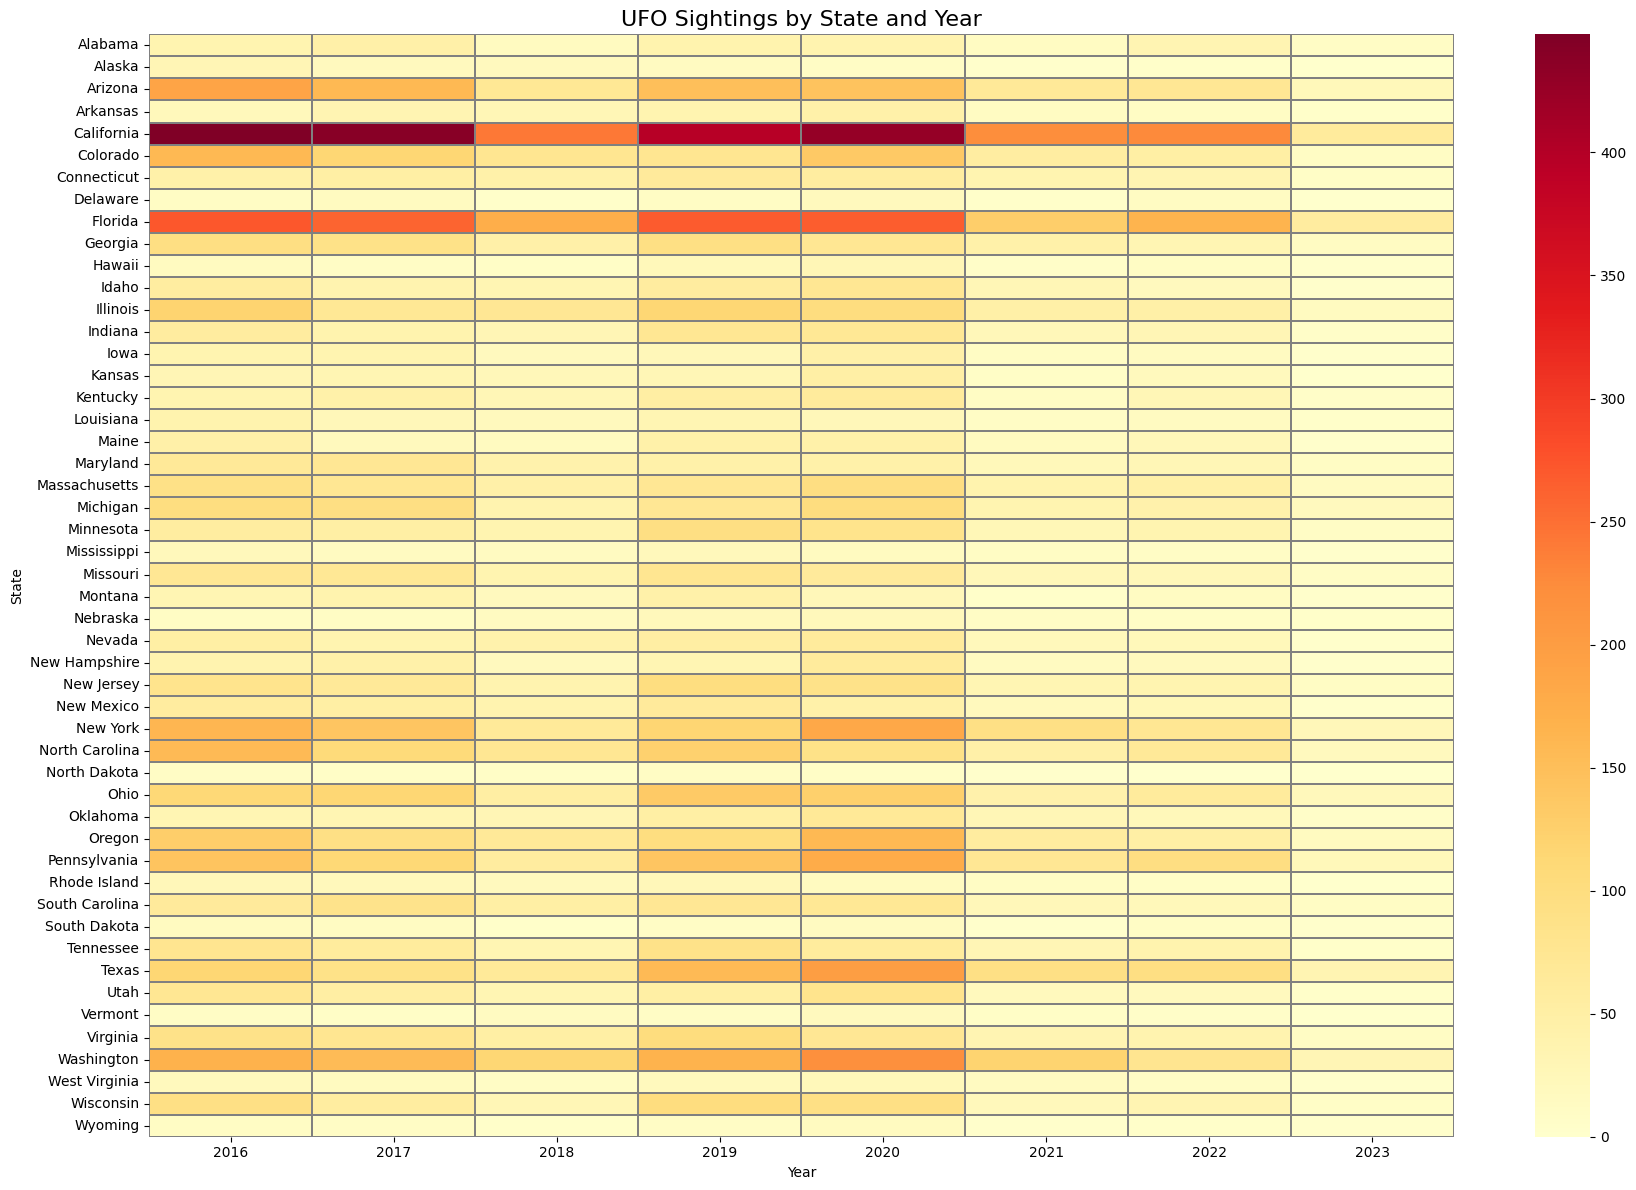

In [2]:
print("hello", flush=True)

#more data cleqaning, we will remove any rows with missing values in the city column
print(df.shape,'shape of the data after dropping duplicates') 
# some more cleaning, we will remove any rows with missing values in the city column
df = df.dropna(subset=["state","year","country_code"]) # remove any rows where city or reported_date_time is missing  
df["full_state_names"] = df["state"].apply(lambda x: us.states.lookup(x).name if us.states.lookup(x) else None)
df = df.dropna(subset=["full_state_names"])

print(df.shape)
df.head(10)
state_counts = df.groupby(["full_state_names", "year"]).size().reset_index(name="report_count")
print(state_counts.head(20))

pivot = state_counts.pivot(index="full_state_names", columns="year", values="report_count").fillna(0)


# plot

pivot = pivot.sort_index()
plt.figure(figsize=(18, 12))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3, linecolor="grey")
plt.title("UFO Sightings by State and Year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("State")
plt.tight_layout()
plt.show()


# Simple Linear Regression Implementation

In [ ]:
import numpy as np
import os

# read through UFO data
df = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2023/2023-06-20/ufo_sightings.csv")
df = df[(df["duration_seconds"] > 0) & (df["duration_seconds"] < 86400)]
df = df[df["state"].notna()]
df["reported_date_time"] = pd.to_datetime(df["reported_date_time"], errors="coerce")
df = df.drop_duplicates()
df = df[["reported_date_time", "country_code", "state"]]
df = df.dropna(subset=["reported_date_time"])
df["year"] = df["reported_date_time"].dt.year
df = df.drop("reported_date_time", axis=1)
df = df[(df["year"] <= 2023) & (df["year"] >= 2016) & (df["country_code"] == "US")]
df = df.dropna(subset=["state", "year", "country_code"])
df["full_state_names"] = df["state"].apply(lambda x: us.states.lookup(x).name if us.states.lookup(x) else None)
df = df.dropna(subset=["full_state_names"])
state_counts = df.groupby(["full_state_names", "year"]).size().reset_index(name="report_count")

# read through climate data
climate_dfs = []
for filename in os.listdir("climate_data"):   
    if filename.endswith(".csv"):
        state_name = filename.replace(".csv", "").title()
        temp_df = pd.read_csv(f"climate_data/{filename}", skiprows=2)  
        temp_df["full_state_names"] = state_name
        climate_dfs.append(temp_df)

climate = pd.concat(climate_dfs, ignore_index=True)
climate["year"] = climate["Date"].astype(str).str[:4].astype(int)
climate_agg = (
    climate.groupby(["full_state_names", "year"])["Value"]
    .mean()
    .reset_index(name="avg_temp")
)
climate_agg = climate_agg[(climate_agg["year"] >= 2016) & (climate_agg["year"] <= 2023)]

merged = state_counts.merge(climate_agg, on=["full_state_names", "year"], how="inner")
print(f"Merged shape: {merged.shape}")
print(merged.head())

class SimpleLinearRegression:
    def __init__(self):
        self.coefficient_ = None
        self.intercept_ = None
        self.r2score_ = None
        
    def fit(self, X, y):
        n = len(X)
        X_b = np.c_[np.ones((n,1)), X]  
   
        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.intercept_ = self.coefficients_[0]
        y_pred = X_b.dot(self.coefficients_)
        # R²
        self.r2score_ = 1 - (np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2))
        self.y_pred_ = y_pred
        
    def predict(self, X):
        X_b = np.c_[np.ones((len(X),1)), X]
        return X_b.dot(self.coefficients_)

Merged shape: (311, 4)
  full_state_names  year  report_count   avg_temp
0          Alabama  2016            36  65.341667
1          Alabama  2017            47  65.033333
2          Alabama  2018            17  64.450000
3          Alabama  2019            40  65.375000
4          Alabama  2020            38  64.866667


Coefficient (slope): 1.5552
Intercept:           -25.8936
R² Score:            0.0453


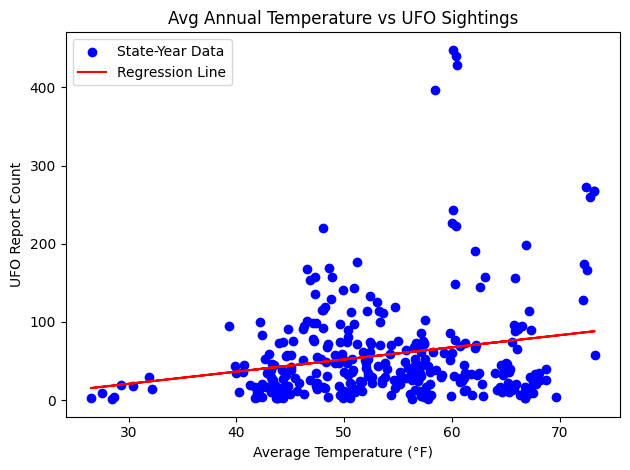

In [ ]:
X = merged["avg_temp"].values.reshape(-1, 1)
y = merged["report_count"].values

slr = SimpleLinearRegression()
slr.fit(X, y)

print(f"Coefficient (slope): {slr.coefficients_[1]:.4f}")
print(f"Intercept: {slr.intercept_:.4f}")
print(f"R² Score: {slr.r2score_:.4f}")

plt.scatter(X, y, color="blue", label="State-Year Data")
plt.plot(X, slr.y_pred_, color="red", label="Regression Line")
plt.title("Avg Annual Temperature vs UFO Sightings")
plt.xlabel("Average Temperature (°F)")
plt.ylabel("UFO Report Count")
plt.legend()
plt.tight_layout()
plt.show()